# In-Class Assignment 4

_Thursday, September 8, 2026_

_How to use this notebook:_ 

**Locally**: Hover over the download symbol then to the `ipynb` option then **right-click** to _Save Link As_ to download the file. You can then open the notebook using `jupyter notebook ica4.ipynb` in your terminal.

**Remote**: You can open the notebook on Colab by hovering over the rocket symbol then select launch to colab. In doing so, any data needed for the plots can be click and dragged to the online workbook. By default, the file will go to `/content/` or `/content/sample_data`

**Credit: These exercises follow from work by Mike Zingale's computational lectures.**

---

## Exploring Equation of State Regimes and Pressure Sources

**Work in groups of 3/4**

## Learning Objectives

* continue to explore EOS regimes
* label various EOS regimes - including QM effects
* plot stellar profiles in EOS regimes
* compare massive, low mass, and evolved stars in the $T-\rho$ space

We will be picking up from ICA3. These exercises require the solutions from ICA3 and are included here. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# constants
m_e = 9.11e-28
m_u = 1.66e-24
c = 3.e10
k = 1.38e-16
h = 6.63e-27
a = 5.67e-15
e = 4.8e-10 # esu

# crystallization
Gamma_C = 170

# define our systems
mu_e = 2
mu_I = 1.0

mu = 1.0 / (1.0/mu_e + 1.0/mu_I)

Z = 1.0

In [3]:
# Fermi momentum constant (from number density integral) - eqn 3.38 in pols
B = (8.0*np.pi/3.0)*m_u*(m_e*c/h)**3

def deg_ideal(rho, mu_e=2.0):
    """temperature on the line separating degeneracy and ideal gas as a function
 of rho"""

    # dimensionless Fermi momentum
    x_F = (rho / mu_e / B)**(1./3.)

    # set E_F = k T
    T = (1./k) * m_e * c**2 * (np.sqrt(1 + x_F**2) - 1)

    return T

In [4]:
def rad_ideal(rho, mu=0.5):
    """temperature on the line separating radiation and ideal gas as a function 
of rho"""

    T = ((3 * k / (m_u * a)) * (rho / mu))**(1./3.)
    return T

In [5]:
def crystallization(rho):
    """temperature where crystallization of ions sets in"""

    T = ((rho / mu_I) * (Z**2 * e**2 / (Gamma_C * k))**3 * (4.0 * np.pi / 3.0 / 
m_u))**(1./3.)
    return T

## a. Plotting MESA History data and EOS regimes II

### **Individually/with the person next to you**:

> You can (and should resuse your plot from last time as a starting point -- or can fill this one out again).

#### **Download or reuse**
The model files are again:

* $1 M_\odot$: [M1_default_trimmed_history.data](data/M1_default_trimmed_history.data)

* $8 M_\odot$: [M8_basic_co_trimmed_history.data](data/M8_basic_co_trimmed_history.data)

* $15 M_\odot$: [M15_aprox21_trimmed_history.data](data/M15_aprox21_trimmed_history.data)

#### Load the MESA history (time evolution properties of quantities, as opposed to _profiles_)
2. load the MESA data using pandas 
3. load the central temperature and density history data for both models

#### Label

4. Update our labels for electron degeneracy with their new definitions and the corresponding pressure eqns.

#### Plot

5. Plot and label the $1M_{\odot}$, **and** $8M_{\odot}$, and $15M_{\odot}$ models.

In [6]:
import pandas as pd
#one_m_sun = pd.read_csv('data/M1_default_trimmed_history.data',sep=r'\s+',header=4)
#eight_m_sun = pd.read_csv('data/M8_basic_co_trimmed_history.data',sep=r'\s+',header=4)
#fifteen_m_sun = pd.read_csv('data/M15_aprox21_trimmed_history.data',sep=r'\s+',header=4)
#one_m_sun.columns

In [7]:
# import T_center and Rho_center history data
#one_m_sun_rho = one_m_sun['log_center_Rho']
#one_m_sun_T= one_m_sun['log_center_T']

#eight_m_sun_rho = eight_m_sun['log_center_XVAR']
#eight_m_sun_T= eight_m_sun['log_center_YVAR']

#fifteen_m_sun_rho = fifteen_m_sun['log_center_XVAR']
#fifteen_m_sun_T= fifteen_m_sun['log_center_YVAR']

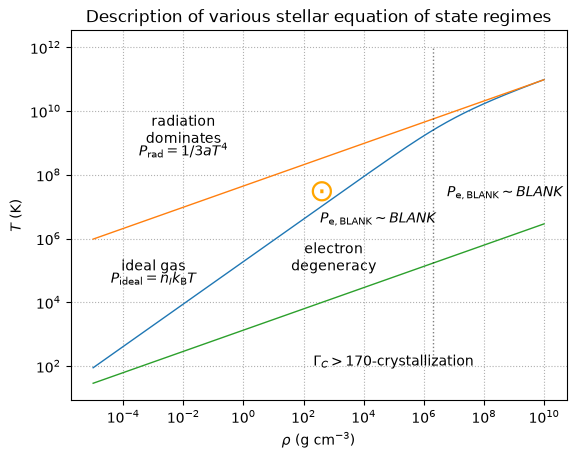

In [8]:
# create an array of densities over which we will plot
rho = np.logspace(-5, 10, 2000)

fig = plt.figure()
ax = fig.add_subplot(111)

# plot the three boundary lines here
ax.plot(rho, deg_ideal(rho),lw=1)
ax.plot(rho, rad_ideal(rho),lw=1)
ax.plot(rho, crystallization(rho),lw=1)

# NEW - now, add mesa data here for Tc, Rhoc
#ax.plot(10**(one_m_sun_rho),10**(one_m_sun_T),label='1$M_{\odot}$',color='lightseagreen',ls='-.')
#ax.plot(10**(eight_m_sun_rho),10**(eight_m_sun_T),label='8$M_{\odot}$',color='rebeccapurple',ls='-.')
#ax.plot(10**(fifteen_m_sun_rho),10**(fifteen_m_sun_T),label='15$M_{\odot}$',color='dodgerblue',ls='-.')

# label / annotate here
ax.text(1.e-2, 1.e9, "radiation\ndominates", horizontalalignment="center")
ax.text(1.e-2, 4e8, r"$P_{\rm{rad}}=1/3aT^4$", horizontalalignment="center")


ax.text(1.e-3, 1.e5, "ideal gas", horizontalalignment="center")
ax.text(1.e-3, 4.e4, r"$P_{\rm{ideal}}=n_{I} k_{\rm{B}} T$", horizontalalignment="center")

# NR vs ER degeneracy
rho_nr_to_er = B*mu_e
ax.vlines(rho_nr_to_er, 1.e2, 1.e12, color='k', ls=":",lw=1,alpha=0.5)

ax.text(1.e3, 1.e5, "electron\ndegeneracy", horizontalalignment="center")
ax.text(3.e4, 3.e6, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")
ax.text(5.e8, 2.e7, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")


ax.text(1.e5, 1.e2, "$\Gamma_{C}>170$-crystallization", horizontalalignment="center")


plt.title(r'Description of various stellar equation of state regimes')


# label the Sun on this diagram using the central density temperatures of the Sun
# solar cheat sheet lives here :https://solar-center.stanford.edu/vitalstats.html
ax.text(150, 1.5e7, "⊙",color='orange',fontsize=22)

# uncomment when you plot the MESA data
#ax.legend()

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\rho~ (\rm{g} \ \rm{cm}^{-3}$)")
ax.set_ylabel("$T$ (K)")
ax.grid(ls=":")

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> We discussed that some gases can be only partially degenerate, rank the three stellar models in order of **most strongly electron degenerate to least** at the end of their evolution and explain your ordering.

    A thoughtful response. 

## b. Plotting MESA Profile data and EOS regimes II

### **Individually/with the person next to you**:

#### **Download**
The model files:

* $1 M_\odot$ Star on the MS: [1m_ms_profile.data](data/1m_ms_profile.data)

* $M_{\rm{ZAMS}}=1 M_\odot\rightarrow 0.6M_{\odot}$ C/O White Dwarf: [co_wd_profile.data](data/co_wd_profile.data)

* $15 M_\odot$ Massive Star during core-O burning: [15m_core_O_burning_profile.data](15m_core_O_burning_profile.data)


#### Copy

1. Copy the completed and labeled plot from a. and use here below. We will add to this plot. 

#### Load the MESA profile (structure properties as a function of spatial coordinate - radius or mass etc)
2. load the MESA data using pandas for the **first two models only**
3. load the temperature and density profile data for both models

#### Plot and Label

4. Plot and label the $1M_{\odot}$ and $0.6M_{\odot}$ CO WD models.

5. In a seperate cell, plot and label the $15M_{\odot}$ model.

In [9]:
#one_m_sun_ms_profile = pd.read_csv('data/1m_ms_profile.data',sep=r'\s+',header=4)
#one_m_sun_ms_profile.columns

#co_wd_profile = pd.read_csv('data/co_wd_profile.data',sep=r'\s+',header=4)
#co_wd_profile.columns

In [10]:
# import T and Rho profile data
#one_m_sun_ms_profile_rho = one_m_sun_ms_profile['logRho']
#one_m_sun_ms_profile_T= one_m_sun_ms_profile['logT']

#co_wd_profile_rho = co_wd_profile['logXVar']
#co_wd_profile_T= co_wd_profile['logYVAR']

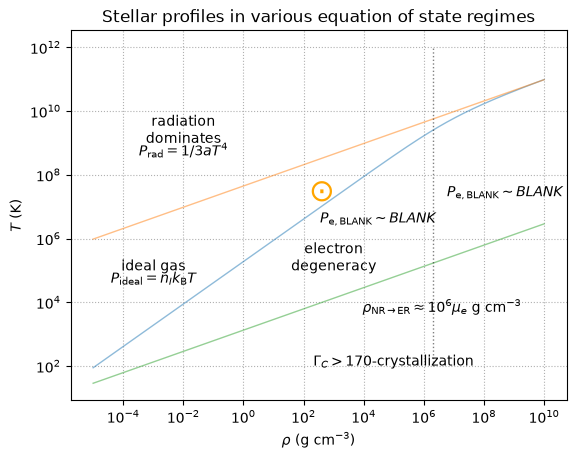

In [11]:
# create an array of densities over which we will plot
rho = np.logspace(-5, 10, 2000)

fig = plt.figure()
ax = fig.add_subplot(111)

# plot the three boundary lines here
ax.plot(rho, deg_ideal(rho),lw=1,alpha=0.5)
ax.plot(rho, rad_ideal(rho),lw=1,alpha=0.5)
ax.plot(rho, crystallization(rho),lw=1,alpha=0.5)


# now, add mesa data here for T, Rho
#ax.plot(10**(one_m_sun_ms_profile_rho),10**(one_m_sun_ms_profile_T),
#        label='1$M_{\odot}$ MS',color='lightseagreen',lw=2)

#ax.plot(10**(co_wd_profile_rho),10**(co_wd_profile_T),
#        label='$0.6M_{\odot} WD$',color='pink',lw=2)


# label / annotate here
ax.text(1.e-2, 1.e9, "radiation\ndominates", horizontalalignment="center")
ax.text(1.e-2, 4e8, r"$P_{\rm{rad}}=1/3aT^4$", horizontalalignment="center")


ax.text(1.e-3, 1.e5, "ideal gas", horizontalalignment="center")
ax.text(1.e-3, 4.e4, r"$P_{\rm{ideal}}=n_{I} k_{\rm{B}} T$", horizontalalignment="center")

# NR vs ER degeneracy
rho_nr_to_er = B*mu_e
ax.vlines(rho_nr_to_er, 1.e2, 1.e12, color='k', ls=":",lw=1,alpha=0.5)
ax.text(4e6, 5e3, r"$\rho_{\rm{NR}\rightarrow\rm{ER}}\approx 10^6 \mu_{e} \ \rm{g \ cm}^{-3}$", horizontalalignment="center")

# you can copy these from a. 
ax.text(1.e3, 1.e5, "electron\ndegeneracy", horizontalalignment="center")
ax.text(3.e4, 3.e6, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")
ax.text(5.e8, 2.e7, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")


ax.text(1.e5, 1.e2, "$\Gamma_{C}>170$-crystallization", horizontalalignment="center")


plt.title(r'Stellar profiles in various equation of state regimes')


# label the Sun on this diagram using the central density temperatures of the Sun
# solar cheat sheet lives here :https://solar-center.stanford.edu/vitalstats.html
ax.text(150, 1.5e7, "⊙",color='orange',fontsize=22)

# uncomment when you plot the MESA data
#ax.legend()


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\rho~ (\rm{g} \ \rm{cm}^{-3}$)")
ax.set_ylabel("$T$ (K)")
ax.grid(ls=":")

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Which model is the star on the main-sequence and which is the CO-WD, how can you tell?

     A thoughtful response. 
    
> For the CO-WD (pink line) which part of the star, in the star is the core and which part is the non-core, envelope or outer layers? Namely, you can say, the core is to the (left or right) in the $T-\rho$ and the envelope is ...

     A thoughtful response. 

In [12]:
# load the fifteen m profile data here
#fifteen_m_sun_core_O_profile = pd.read_csv('data/15m_core_O_burning_profile.data',sep=r'\s+',header=4)
#fifteen_m_sun_core_O_profile.columns

# import T and Rho profile data
#fifteen_m_sun_core_O_profile_rho = fifteen_m_sun_core_O_profile['logRho']
#fifteen_m_sun_core_O_profile_T= fifteen_m_sun_core_O_profile['logT']

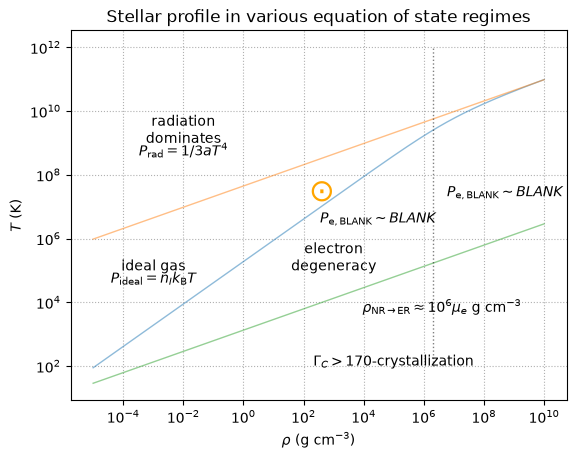

In [13]:
# create an array of densities over which we will plot
rho = np.logspace(-5, 10, 2000)

fig = plt.figure()
ax = fig.add_subplot(111)

# plot the three boundary lines here
ax.plot(rho, deg_ideal(rho),lw=1,alpha=0.5)
ax.plot(rho, rad_ideal(rho),lw=1,alpha=0.5)
ax.plot(rho, crystallization(rho),lw=1,alpha=0.5)


# now, add mesa data here for T, Rho
#ax.plot(10**(fifteen_m_sun_core_O_profile_rho),10**(fifteen_m_sun_core_O_profile_T),
#        label='$15M_{\odot}$ core-O burning',color='magenta',lw=2)


# label / annotate here
ax.text(1.e-2, 1.e9, "radiation\ndominates", horizontalalignment="center")
ax.text(1.e-2, 4e8, r"$P_{\rm{rad}}=1/3aT^4$", horizontalalignment="center")


ax.text(1.e-3, 1.e5, "ideal gas", horizontalalignment="center")
ax.text(1.e-3, 4.e4, r"$P_{\rm{ideal}}=n_{I} k_{\rm{B}} T$", horizontalalignment="center")

# NR vs ER degeneracy
rho_nr_to_er = B*mu_e
ax.vlines(rho_nr_to_er, 1.e2, 1.e12, color='k', ls=":",lw=1,alpha=0.5)
ax.text(4e6, 5e3, r"$\rho_{\rm{NR}\rightarrow\rm{ER}}\approx 10^6 \mu_{e} \ \rm{g \ cm}^{-3}$", horizontalalignment="center")


ax.text(1.e3, 1.e5, "electron\ndegeneracy", horizontalalignment="center")
ax.text(3.e4, 3.e6, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")
ax.text(5.e8, 2.e7, r"$P_{\rm{e},BLANK} \sim BLANK$", horizontalalignment="center")


ax.text(1.e5, 1.e2, "$\Gamma_{C}>170$-crystallization", horizontalalignment="center")


plt.title(r'Stellar profile in various equation of state regimes')


# label the Sun on this diagram using the central density temperatures of the Sun
# solar cheat sheet lives here :https://solar-center.stanford.edu/vitalstats.html
ax.text(150, 1.5e7, "⊙",color='orange',fontsize=22)


#ax.legend(loc=2)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\rho~ (\rm{g} \ \rm{cm}^{-3}$)")
ax.set_ylabel("$T$ (K)")
ax.grid(ls=":")

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Comment qualitatively where the advanced burning massive star model is in the $T-\rho$ diagram compared to our two models above.

    A thoughtful response.
    
> In the low $T$ and low $\rho$, the profile slightly exceeds into the radiation pressure regime. What part of the star is this and what consequences could result for this region of the star.

    A thoughtful response.